In [1]:
import pandas as pd

In [3]:
import numpy as np

In [5]:
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.preprocessing import StandardScaler

In [9]:
import warnings

In [11]:
warnings.filterwarnings("ignore")


In [13]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [15]:
boston_df = pd.read_csv(url)


In [17]:
X_boston = boston_df.drop('medv', axis=1)

In [19]:
y_boston = boston_df['medv']

In [23]:
scaler_boston=StandardScaler()

In [27]:
X_boston_scaled=scaler_boston.fit_transform(X_boston)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_boston_scaled, y_boston, test_size=0.20, random_state=42
)

In [31]:
print("Training set shape:",X_train.shape)

Training set shape: (404, 13)


In [33]:
print("Test set shape:",X_test.shape)

Test set shape: (102, 13)


In [35]:
from sklearn.linear_model import LinearRegression

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [39]:
lr_model = LinearRegression()

In [41]:
lr_model.fit(X_train,y_train)

LinearRegression()

In [43]:
lr_preds =lr_model.predict(X_test)

In [45]:
mae = mean_absolute_error(y_test,lr_preds)

In [47]:
mse = mean_squared_error(y_test,lr_preds)

In [49]:
rmse = np.sqrt(mse)

In [51]:
r2 = r2_score(y_test,lr_preds)

In [53]:
print(f"Mean Absolute Error: {mae:.4f}")

Mean Absolute Error: 3.1891


In [55]:
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 24.2911


In [57]:
print(f"Root Mean Squared Error:{rmse:.4f}")

Root Mean Squared Error:4.9286


In [59]:
print(f"R2 Score:{r2:.4f}")

R2 Score:0.6688


In [68]:
from sklearn.model_selection import train_test_split

In [70]:
from sklearn.preprocessing import StandardScaler

In [72]:
from sklearn.svm import SVR

In [74]:
from sklearn.tree import DecisionTreeRegressor

In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [80]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [82]:
boston_df = pd.read_csv(url)

In [86]:
print(boston_df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [90]:
X = boston_df.drop("medv", axis=1)
y = boston_df["medv"]

In [94]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (404, 13)
Testing Set Shape: (102, 13)


In [98]:
svr = SVR(kernel='rbf')

In [100]:
svr.fit(X_train, y_train)

SVR()

In [102]:
svr_pred = svr.predict(X_test)

In [106]:
print("Support Vector Regression Results")
print("MAE :", mean_absolute_error(y_test, svr_pred))
print("MSE :", mean_squared_error(y_test, svr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, svr_pred)))
print("R2 Score :", r2_score(y_test, svr_pred))

Support Vector Regression Results
MAE : 2.73276896493331
MSE : 25.693036656663203
RMSE : 5.068829910015053
R2 Score : 0.6496425583214102


In [108]:
dtr = DecisionTreeRegressor(random_state=42)

In [110]:
dtr.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [112]:
dtr_pred = dtr.predict(X_test)

In [114]:
print("\nDecision Tree Regression Results")
print("MAE :", mean_absolute_error(y_test, dtr_pred))
print("MSE :", mean_squared_error(y_test, dtr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dtr_pred)))
print("R2 Score :", r2_score(y_test, dtr_pred))


Decision Tree Regression Results
MAE : 2.394117647058824
MSE : 10.416078431372549
RMSE : 3.2273949915330395
R2 Score : 0.8579634380978161


In [116]:
comparison = pd.DataFrame({
    "Model": ["Support Vector Regression", "Decision Tree Regression"],
    "MAE": [
        mean_absolute_error(y_test, svr_pred),
        mean_absolute_error(y_test, dtr_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, svr_pred),
        mean_squared_error(y_test, dtr_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, svr_pred)),
        np.sqrt(mean_squared_error(y_test, dtr_pred))
    ],
    "R2 Score": [
        r2_score(y_test, svr_pred),
        r2_score(y_test, dtr_pred)
    ]
})

print("\nComparative Performance")
print(comparison)


Comparative Performance
                       Model       MAE        MSE      RMSE  R2 Score
0  Support Vector Regression  2.732769  25.693037  5.068830  0.649643
1   Decision Tree Regression  2.394118  10.416078  3.227395  0.857963


In [124]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(),
    X_scaled,
    y,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10)
)


In [126]:
train_error = -train_scores.mean(axis=1)
test_error = -test_scores.mean(axis=1)


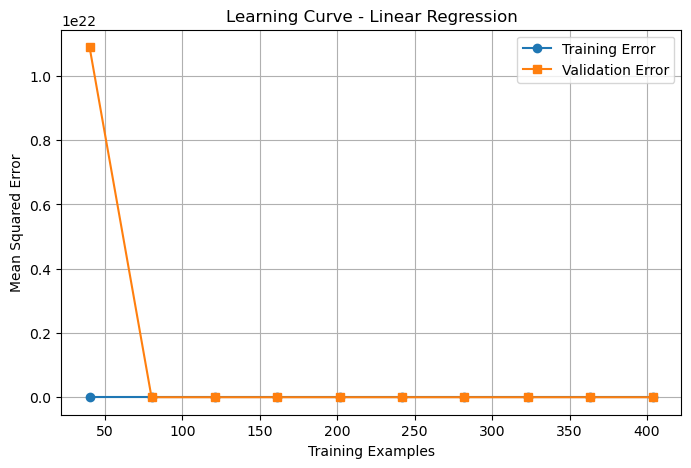

In [150]:
train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(),
    X_scaled,
    y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)
train_error = -train_scores.mean(axis=1)
test_error = -test_scores.mean(axis=1)
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_error,
         marker='o',
         label='Training Error')
plt.plot(train_sizes, test_error,
         marker='s',
         label='Validation Error')
plt.title("Learning Curve - Linear Regression")
plt.xlabel("Training Examples")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()